In [33]:
import numpy as np
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

path = Path("./test_faces")
images = []
for p in path.iterdir():
    img_aux = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img_aux is None:
        continue
    img_res = cv2.resize(img_aux, (100, 100))
    images.append(img_res.flatten())

X = np.array(images).astype(np.float32)
print(X.shape)


(9, 10000)


## In urmatoarea parte calculez fata medie

(10000,)


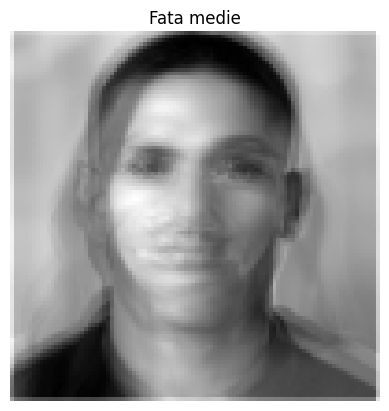

In [34]:
psi = np.mean(X, axis=0)
print(psi.shape)
psi_img = psi.reshape(100, 100)
plt.imshow(psi_img, cmap='gray')
plt.title('Fata medie')
plt.axis('off')
plt.show()

### Noua poza medie

In [37]:
A = X - psi
C = np.dot(A,np.transpose(A))
vect_vals, vect_props = np.linalg.eigh(C)
idx = np.argsort(vect_vals)[::-1]
vect_vals = vect_vals[idx]
vect_props = vect_props[:,idx]
print(A.shape)
print(vect_vals.shape)
print(vect_props.shape)
#print(vect_vals)
#print(vect_props)



(9, 10000)
(9,)
(9, 9)


In [41]:
#eu am A pe randuri, nu coloana , este vect transpus
K = 9
new_V_props = vect_props[:,:K]
print(new_V_props.shape)
u = np.dot(np.transpose(A),new_V_props)
u = u / np.linalg.norm(u, axis=0)
print(u.shape)
w = np.dot(A,u)
print(w.shape)



(9, 9)
(10000, 9)
(9, 9)


### Partea de SVM , antrenare

In [ ]:
y = cv2.imread("./test_faces/test1.png",cv2.IMREAD_GRAYSCALE)
y_res = cv2.resize(y, (100, 100))
y_flat = y_res.flatten()
y_sub = y_flat - psi
